<a href="https://colab.research.google.com/github/NVHau-K14/Tuan04_ThucHanh_DeepLearning/blob/main/CNN_NhanDienChuSo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

2.2. Đọc dữ liệu MNIST

In [ ]:
mnist_train = '/content/mnist_dataset/mnist_train.csv'
mnist_test = '/content/mnist_dataset/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 785)
(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
num_class = 10
input_shape = (28, 28 , 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(60000, 28, 28, 1)
(10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    0
2    4
3    1
4    9
Name: label, dtype: int64


2.3. Trực quan hóa 10 ảnh đầu tiên

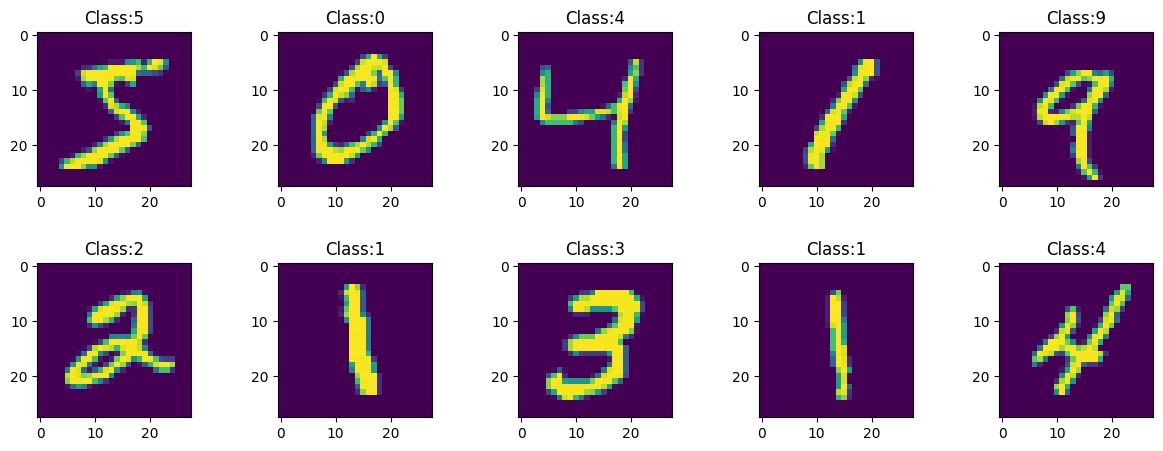

In [ ]:
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace = 0.5)
plt.show()

2.4. Chuyển giá trị nhãn thành one-hot encoding

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_class)
y_test = keras.utils.to_categorical(y_test, num_class)

2.5. Xây dựng mô hình CNN

In [ ]:
model = Sequential()
model.add(Input(shape = input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(units = 10, activation = 'softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,578 (68.66 KB)

 Trainable params: 17,578 (68.66 KB)

 Non-trainable params: 0 (0.00 B)

2.6. Huấn luyện mô hình CNN

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose = 1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8940 - loss: 0.3750 - val_accuracy: 0.9737 - val_loss: 0.0967
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9695 - loss: 0.1014 - val_accuracy: 0.9778 - val_loss: 0.0725
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9775 - loss: 0.0751 - val_accuracy: 0.9802 - val_loss: 0.0702
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9807 - loss: 0.0622 - val_accuracy: 0.9847 - val_loss: 0.0555
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9828 - val_loss: 0.0590
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9859 - loss: 0.0456 - val_accuracy: 0.9878 - val_loss: 0.0442
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9872 - loss: 0.0421 - val_accuracy: 0.9872 - val_loss: 0.0421
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0377 - val_accuracy: 0

2.7. Đánh giá mô hình CNN

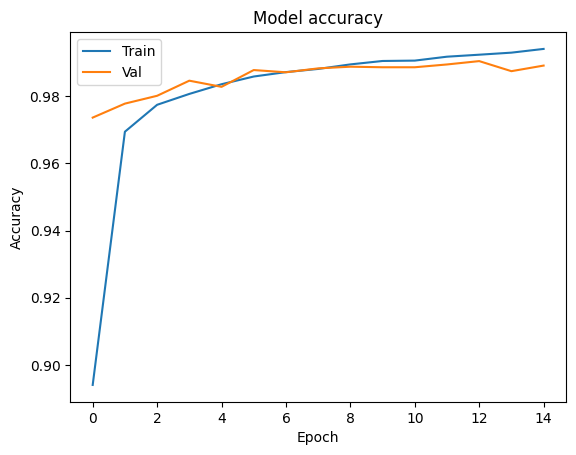

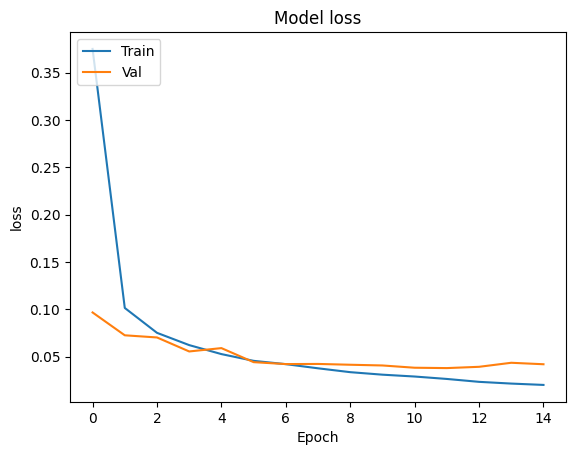

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 6ms/step - accuracy: 0.9885 - loss: 0.0346
Test loss: 0.03461842238903046
Test accuracy: 0.9884999990463257


2.9. Dự báo nhã cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
[[9.6842317e-12 3.0580753e-11 6.7625763e-07 1.7663887e-06 3.8152770e-15
  2.1749506e-10 2.2200186e-18 9.9999726e-01 1.3253747e-08 3.4123434e-07]]
7 7


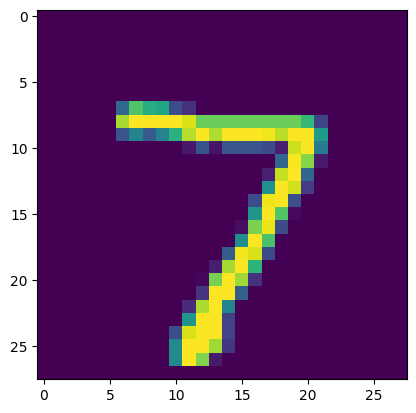

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

Tải ảnh lên để dự đoán

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


uploaded = files.upload()

for file_name in uploaded.keys():

    img = Image.open(file_name).convert("L")

    img = img.resize((28, 28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array.astype("float32") / 255.0

    plt.imshow(img_array, cmap="gray")
    plt.title("Ảnh sau xử lý")
    plt.axis("off")
    plt.show()

    img_input = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_input)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    print("\n========== KẾT QUẢ DỰ ĐOÁN ==========")
    print("File ảnh:", file_name)
    print("Class dự đoán:", predicted_class)
    print(f"Độ tin cậy: {confidence:.2f}%")

    print("\nXác suất từng class:")
    for i, prob in enumerate(prediction[0]):
        print(f"Class {i}: {prob * 100:.2f}%")

2.10. Lưu tham số mô hình

In [ ]:
model.save_weights('cnn.h5')

2.11. Nạp lại mô hình và tham số

In [ ]:
model = Sequential()
model.add(Input(shape = input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(units = 10, activation = 'softmax'))
model.load_weights('cnn.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()